# Adversarial Multi-Agent Debate System

## Overview
A sophisticated LangGraph-based multi-agent system where AI personas with opposing viewpoints debate controversial topics, critique each other's arguments, and converge on balanced, well-reasoned conclusions through iterative refinement cycles.

## Motivation
Single LLM responses are inherently biased, often presenting one-sided perspectives on complex topics. This leads to users making decisions based on incomplete information. My solution provides automated balanced analysis through adversarial debate — free, instant, and comprehensive.

## What Makes This Advanced
- **Cyclic graph architecture** with conditional routing and loops
- **Multi-agent coordination** with specialized personas (Proponent, Opponent, Critic, Moderator, Synthesis)
- **Quality-driven iteration** where agents improve each round until quality thresholds are met
- **Human-in-the-Loop** — you can review intermediate results and request refinements
- **Free tools** (DuckDuckGo, Wikipedia) for evidence-backed arguments
- **Fast inference** powered by Groq's LPU hardware (llama-3.1-8b-instant)

## System Architecture

```
USER QUERY → MODERATOR → PROPONENT → OPPONENT → CRITIC → QUALITY GATE → HITL → SYNTHESIS → OUTPUT
                              ↑                          |
                              └── (loop if quality low) ──┘
```

### The 6 Agent Personas:
1. **Moderator** - Analyzes the query, defines debate structure
2. **Proponent** - Argues IN FAVOR of the topic with evidence
3. **Opponent** - Argues AGAINST the topic with counter-evidence
4. **Critic** - Evaluates argument quality (1-10), detects fallacies
5. **Human-in-the-Loop** - You review and provide feedback before final synthesis
6. **Synthesis** - Combines best arguments into a balanced conclusion

The debate runs for up to 5 rounds, but can exit early once quality exceeds the threshold (7.5/10).

## Step 1: Install Dependencies

In [46]:
!pip install langchain langchain-community wheel langchain-core langgraph python-dotenv duckduckgo_search wikipedia langchain-groq ddgs --quiet


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Load Environment Variables

Create a `.env` file in the project root with your API keys. The `.env` file is in `.gitignore` and will not be committed.

For this implementation we use **Groq** (fast LPU inference). Configure it in `.env`:
```
GROQ_API_KEY="gsk_your_api_key_here"
GROQ_MODEL="llama-3.1-8b-instant"
```
> **Note:** You can swap to any OpenAI-compatible provider by changing the LLM init below.

In [59]:
from dotenv import load_dotenv
import os

load_dotenv()

# Read .env values (manual fallback for robustness)
if not os.getenv("GROQ_API_KEY"):
    env_path = ".env"
    if os.path.exists(env_path):
        with open(env_path, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    key, val = line.split("=", 1)
                    val = val.strip().strip('\"').strip("'")
                    os.environ[key.strip()] = val

GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")

print(f"Using Groq Inference")
print(f"Model: {GROQ_MODEL}")
key_preview = GROQ_API_KEY[:8] + "..." + GROQ_API_KEY[-4:] if GROQ_API_KEY else "NOT SET"
print(f"API Key: {key_preview}")

Using Groq Inference
Model: llama-3.1-8b-instant
API Key: gsk_0NWk...tyxb


## Step 3: Imports

In [60]:
import json
import time
from typing import TypedDict, List, Annotated
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_groq import ChatGroq

print("All imports successful")

All imports successful


## Step 4: LLM Initialization

We use `ChatGroq` from langchain to access Groq's LPU inference engine for blazing-fast responses.

> **Note:** Groq's free tier limits output to **6,000 tokens per minute** for `llama-3.1-8b-instant`. If the synthesis step fails with a 413 error, upgrade to [Dev Tier](https://console.groq.com/settings/billing) or use a different provider. The synthesis agent truncates debate history to stay within limits.

In [61]:
def get_llm(temperature: float = 0.7):
    return ChatGroq(
        model=GROQ_MODEL,
        temperature=temperature,
        api_key=GROQ_API_KEY,
    )


# Quick test
test_llm = get_llm()
print(f"LLM initialized: {type(test_llm).__name__} with model {GROQ_MODEL}")

LLM initialized: ChatGroq with model llama-3.1-8b-instant


## Step 5: Define Tools (All Free, No API Keys Required)

We use two free tools that require zero configuration:
- **DuckDuckGo Search**: Web search for current evidence, news, and data
- **Wikipedia**: Factual background information on any topic

In [62]:
# Initialize tool runners
duckduckgo_runner = DuckDuckGoSearchRun()
wikipedia_runner = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

# Wrap with @tool decorator for proper type annotations
@tool
def duckduckgo_search(query: str) -> str:
    """Search the web for current information, news, and data."""
    return duckduckgo_runner.run(query)

@tool
def wikipedia(query: str) -> str:
    """Search Wikipedia for factual background information on any topic."""
    return wikipedia_runner.run(query)

tools = [duckduckgo_search, wikipedia]

print(f"Tools initialized: {[t.name for t in tools]}")
print("DuckDuckGoSearch requires no API key")
print("Wikipedia requires no API key")

Tools initialized: ['duckduckgo_search', 'wikipedia']
DuckDuckGoSearch requires no API key
Wikipedia requires no API key


## Step 6: Define State Schema

The `DebateState` holds all information flowing through the graph — user input, debate history, quality scores, and final output.

In [63]:
class DebateState(TypedDict):
    user_query: str
    topic: str

    debate_rounds: int
    max_rounds: int
    quality_threshold: float

    proponent_messages: Annotated[List[str], operator.add]
    opponent_messages: Annotated[List[str], operator.add]
    critic_feedback: Annotated[List[dict], operator.add]

    current_round: int
    quality_scores: dict

    avg_quality_score: float
    logic_fallacies_found: List[str]

    synthesis: str
    debate_summary: str

    # Human-in-the-loop
    user_feedback: str
    needs_human_intervention: bool


print("DebateState schema defined")
print(f"Fields: {list(DebateState.__annotations__.keys())}")

DebateState schema defined
Fields: ['user_query', 'topic', 'debate_rounds', 'max_rounds', 'quality_threshold', 'proponent_messages', 'opponent_messages', 'critic_feedback', 'current_round', 'quality_scores', 'avg_quality_score', 'logic_fallacies_found', 'synthesis', 'debate_summary', 'user_feedback', 'needs_human_intervention']


## Step 7: Helper Functions for Rich Output

We use ANSI color codes and formatted printing to make the debate process easy to follow in a terminal.

In [64]:
# ANSI color codes
C = {
    "reset": "\033[0m",
    "bold": "\033[1m",
    "dim": "\033[2m",
    "red": "\033[91m",
    "green": "\033[92m",
    "yellow": "\033[93m",
    "blue": "\033[94m",
    "magenta": "\033[95m",
    "cyan": "\033[96m",
    "white": "\033[97m",
}


def pprint_separator(char="=", width=80, color="cyan"):
    print(f"{C[color]}{char * width}{C['reset']}")


def pprint_header(text, color="cyan"):
    pprint_separator(color=color)
    print(f"{C[color]}{C['bold']}{text}{C['reset']}")
    pprint_separator(color=color)


def pprint_subheader(text, color="yellow"):
    print(f"{C[color]}{C['bold']}  >>> {text}{C['reset']}")


def pprint_info(label, value, color="white"):
    print(f"{C['dim']}  {label}:{C['reset']} {C[color]}{value}{C['reset']}")


def pprint_round(round_num, max_rounds, quality=None):
    qual = f" | Quality: {quality:.1f}/10" if quality is not None else ""
    pprint_separator("-", 60, "magenta")
    print(f"{C['magenta']}{C['bold']}  ROUND {round_num}/{max_rounds}{qual}{C['reset']}")
    pprint_separator("-", 60, "magenta")


def pprint_agent(agent_name, text, color="green"):
    label = f"{C[color]}{C['bold']}[{agent_name}]{C['reset']}"
    # Truncate very long responses for inline display
    lines = text.strip().split("\n")
    preview = " ".join(lines[:3])[:200]
    print(f"{label} {preview}..." if len(text) > 200 else f"{label} {preview}")
    print()


print("Output helpers initialized")

Output helpers initialized


## Step 8: Implement Agent Node Functions

### 8.1 Moderator Agent

The moderator analyzes the user's query, identifies the core controversy, sets up the debate structure, and initializes all state fields.

In [65]:
def moderator_agent(state: DebateState) -> DebateState:
    pprint_subheader("Moderator analyzing query...", "cyan")

    llm = get_llm(temperature=0.5)

    prompt = f"""
    You are a neutral debate moderator. Analyze this topic:

    "{state['user_query']}"

    Tasks:
    1. Identify the core controversial question
    2. Define what the proponent side should argue (YES/PRO)
    3. Define what the opponent side should argue (NO/CON)
    4. Explain why this topic benefits from adversarial debate

    Keep your response concise and structured.
    """

    result = llm.invoke(prompt)

    print(f"  {C['dim']}Moderator setup complete.{C['reset']}")

    return {
        "topic": state["user_query"],
        "debate_rounds": 0,
        "max_rounds": 5,
        "quality_threshold": 7.5,
        "current_round": 1,
        "proponent_messages": [f"MODERATOR SETUP:\n{result.content}"],
        "opponent_messages": [],
        "critic_feedback": [],
        "quality_scores": {},
        "avg_quality_score": 0.0,
        "logic_fallacies_found": [],
        "synthesis": "",
        "debate_summary": "",
        "user_feedback": "",
        "needs_human_intervention": False,
    }

### 8.2 Proponent Agent

The proponent argues IN FAVOR of the topic. It uses DuckDuckGo and Wikipedia to find supporting evidence and counters the opponent's previous arguments.

In [66]:
def proponent_agent(state: DebateState) -> DebateState:
    pprint_agent("Proponent (FOR)", "Researching and constructing supporting arguments...", "green")

    llm = get_llm(temperature=0.7)
    agent = create_agent(model=llm, tools=tools)

    last_opponent = state["opponent_messages"][-1] if state["opponent_messages"] else "None yet"
    last_critic = state["critic_feedback"][-1] if state["critic_feedback"] else "None yet"

    prompt = f"""
    You are the PROPONENT in this debate. Your task is to argue IN FAVOR of:
    "{state['topic']}"

    Current round: {state['current_round']}/{state['max_rounds']}

    Previous opponent arguments to counter:
    {last_opponent}

    Critic feedback from last round:
    {json.dumps(last_critic, indent=2) if isinstance(last_critic, dict) else last_critic}

    Your goals:
    1. Present strong, evidence-based arguments FOR the topic
    2. Use duckduckgo_search to find recent supporting evidence
    3. Use wikipedia for factual background
    4. Directly address and counter the opponent's points
    5. Improve based on critic's previous feedback

    Structure your argument:
    - Main claim
    - Supporting evidence (with citations from search results)
    - Logical reasoning
    - Counter to opponent's points
    """

    try:
        result = agent.invoke({"messages": [HumanMessage(content=prompt)]})
        argument = result["messages"][-1].content
    except Exception as e:
        argument = f"[Proponent agent error: {str(e)}. Using fallback response.]\n"
        fallback = llm.invoke(prompt)
        argument += fallback.content

    pprint_agent("Proponent", argument, "green")

    return {
        "proponent_messages": [argument],
        "debate_rounds": state["debate_rounds"] + 1,
    }

### 8.3 Opponent Agent

The opponent argues AGAINST the topic. It mirrors the proponent's structure but takes the opposing stance.

In [67]:
def opponent_agent(state: DebateState) -> DebateState:
    pprint_agent("Opponent (AGAINST)", "Researching and constructing counter-arguments...", "red")

    llm = get_llm(temperature=0.7)
    agent = create_agent(model=llm, tools=tools)

    last_proponent = state["proponent_messages"][-1] if state["proponent_messages"] else "None yet"
    last_critic = state["critic_feedback"][-1] if state["critic_feedback"] else "None yet"

    prompt = f"""
    You are the OPPONENT in this debate. Your task is to argue AGAINST:
    "{state['topic']}"

    Current round: {state['current_round']}/{state['max_rounds']}

    Previous proponent arguments to counter:
    {last_proponent}

    Critic feedback from last round:
    {json.dumps(last_critic, indent=2) if isinstance(last_critic, dict) else last_critic}

    Your goals:
    1. Present strong, evidence-based arguments AGAINST the topic
    2. Use duckduckgo_search to find recent opposing evidence
    3. Use wikipedia for factual background
    4. Directly address and rebut the proponent's points
    5. Improve based on critic's previous feedback

    Structure your argument:
    - Main counter-claim
    - Supporting evidence (with citations from search results)
    - Logical reasoning
    - Rebuttal to proponent's points
    """

    try:
        result = agent.invoke({"messages": [HumanMessage(content=prompt)]})
        argument = result["messages"][-1].content
    except Exception as e:
        argument = f"[Opponent agent error: {str(e)}. Using fallback response.]\n"
        fallback = llm.invoke(prompt)
        argument += fallback.content

    pprint_agent("Opponent", argument, "red")

    return {
        "opponent_messages": [argument],
    }

### 8.4 Critic Agent

The critic evaluates both sides of the debate and returns quality scores (1-10), specific feedback for improvement, and detected logical fallacies.

In [68]:
def critic_agent(state: DebateState) -> DebateState:
    pprint_subheader("Critic evaluating both arguments...", "yellow")

    llm = get_llm(temperature=0.3)

    prompt = f"""
    You are a neutral, expert debate critic. Evaluate both sides of the debate on:
    "{state['topic']}"

    Proponent's argument (FOR):
    {state['proponent_messages'][-1]}

    Opponent's argument (AGAINST):
    {state['opponent_messages'][-1]}

    Evaluation criteria:
    1. Evidence Quality (1-10): Are claims backed by credible sources?
    2. Logical Consistency (1-10): Are arguments logically sound?
    3. Relevance (1-10): Do arguments directly address the topic?
    4. Counterargument Strength (1-10): How well do they address opposing views?
    5. Fallacies (list): Identify any logical fallacies

    Provide your evaluation in valid JSON format ONLY:
    {{
        "proponent_scores": {{
            "evidence_quality": 0,
            "logical_consistency": 0,
            "relevance": 0,
            "counterargument_strength": 0
        }},
        "opponent_scores": {{
            "evidence_quality": 0,
            "logical_consistency": 0,
            "relevance": 0,
            "counterargument_strength": 0
        }},
        "proponent_feedback": "Specific feedback for proponent",
        "opponent_feedback": "Specific feedback for opponent",
        "fallacies": ["list of logical fallacies found"],
        "avg_quality": 0.0
    }}
    """

    try:
        result = llm.invoke(prompt)
        content = result.content.strip()
        if content.startswith("```json"):
            content = content[7:]
        if content.endswith("```"):
            content = content[:-3]
        feedback = json.loads(content)
    except Exception as e:
        feedback = {
            "proponent_scores": {
                "evidence_quality": 5, "logical_consistency": 5,
                "relevance": 5, "counterargument_strength": 5
            },
            "opponent_scores": {
                "evidence_quality": 5, "logical_consistency": 5,
                "relevance": 5, "counterargument_strength": 5
            },
            "proponent_feedback": "Evaluation parse failed. Default scores used.",
            "opponent_feedback": "Evaluation parse failed. Default scores used.",
            "fallacies": ["Unable to evaluate"],
            "avg_quality": 5.0
        }

    # Print quality summary
    avg = feedback["avg_quality"]
    color = "green" if avg >= 7.5 else ("yellow" if avg >= 5.0 else "red")
    pprint_info("Avg Quality", f"{avg}/10", color)
    pprint_info("Fallacies", ", ".join(feedback["fallacies"]), "yellow")

    return {
        "critic_feedback": [feedback],
        "quality_scores": {
            "proponent": feedback["proponent_scores"],
            "opponent": feedback["opponent_scores"],
        },
        "avg_quality_score": feedback["avg_quality"],
        "logic_fallacies_found": feedback["fallacies"],
        "current_round": state["current_round"] + 1,
    }

### 8.5 Quality Gate (Conditional Edge)

This function decides whether to continue debating or proceed to human review. The debate loops back if:
1. Quality is below the threshold (7.5/10), AND
2. We haven't exceeded the maximum rounds (5)

In [69]:
def quality_gate(state: DebateState) -> str:
    current_round = state.get("current_round", 1)
    max_rounds = state.get("max_rounds", 5)
    avg_quality = state.get("avg_quality_score", 0.0)
    threshold = state.get("quality_threshold", 7.5)

    if current_round > max_rounds:
        print(f"  {C['yellow']}Max rounds ({max_rounds}) reached. Proceeding to human review.{C['reset']}")
        return "ask_human"

    if avg_quality >= threshold:
        print(f"  {C['green']}Quality ({avg_quality:.1f}) >= threshold ({threshold}). Proceeding to human review.{C['reset']}")
        return "ask_human"

    print(f"  {C['magenta']}Round {current_round}: Quality {avg_quality:.1f} < {threshold}. Continuing debate...{C['reset']}")
    return "continue_debate"

### 8.6 Human-in-the-Loop Node

Before generating the final synthesis, the system pauses and asks you to review the debate so far. You can:
- **Approve** — proceed to final synthesis
- **Provide feedback** — request specific refinements and loop back for another round
- **Add new evidence** — suggest sources or angles for the agents to explore

In [70]:
def human_feedback_node(state: DebateState) -> DebateState:
    """
    Pauses the graph and prompts the user for feedback before synthesis.
    """
    pprint_header("HUMAN REVIEW", "cyan")
    print(f"{C['bold']}Topic:{C['reset']} {state['topic']}")
    print(f"{C['bold']}Rounds completed:{C['reset']} {state['current_round']}")
    print(f"{C['bold']}Current quality:{C['reset']} {state.get('avg_quality_score', 0):.1f}/10")
    print()

    fallacies = state.get("logic_fallacies_found", [])
    if fallacies:
        print(f"{C['yellow']}Logical fallacies detected:{C['reset']}")
        for f in fallacies:
            print(f"   • {f}")
        print()

    print(f"{C['bold']}What would you like to do?{C['reset']}")
    print(f"  [{C['green']}a{C['reset']}] Approve — proceed to final synthesis")
    print(f"  [{C['yellow']}f{C['reset']}] Provide feedback — request refinements (one more round will run)")
    print(f"  [{C['red']}q{C['reset']}] Quit — end without synthesis")

    choice = input(f"\n{C['cyan']}Your choice (a/f/q):{C['reset']} ").strip().lower()

    if choice == "a":
        print(f"\n{C['green']}Approved! Generating final synthesis...{C['reset']}")
        return {
            "user_feedback": "APPROVED",
            "needs_human_intervention": False,
        }

    elif choice == "f":
        feedback = input(f"\n{C['yellow']}Your feedback for the agents:{C['reset']} ").strip()
        print(f"\n{C['yellow']}Feedback recorded. Running another round with your input...{C['reset']}")
        return {
            "user_feedback": feedback,
            "needs_human_intervention": False,
            "current_round": state.get("current_round", 1) + 1,
        }

    else:
        print(f"\n{C['red']}Debate ended without synthesis.{C['reset']}")
        return {
            "user_feedback": "QUIT",
            "needs_human_intervention": False,
        }

### 8.7 Human Review Router

Decides where to go after the human feedback node.

In [71]:
def human_router(state: DebateState) -> str:
    """Routes after human feedback."""
    feedback = state.get("user_feedback", "")
    if feedback == "APPROVED":
        return "synthesize"
    elif feedback == "QUIT":
        return "end"
    else:
        # User provided custom feedback — loop back for another round
        return "continue_debate"

### 8.8 Synthesis Agent

After the debate concludes, the synthesis agent creates a balanced, nuanced conclusion incorporating the best arguments from both sides.

In [72]:
def synthesis_agent(state: DebateState) -> DebateState:
    pprint_subheader("Synthesizing balanced conclusion...", "cyan")

    llm = get_llm(temperature=0.5)

    # Build context including user feedback if any
    user_feedback_context = ""
    if state.get("user_feedback") and state["user_feedback"] not in ("APPROVED", "QUIT"):
        user_feedback_context = f"\nUser's feedback/request: {state['user_feedback']}\nPlease incorporate this feedback into your synthesis.\n"

    prompt = f"""
    You are a neutral synthesis expert. Create a balanced, nuanced conclusion for the debate on:
    "{state['topic']}"
    {user_feedback_context}

    # Truncate each argument to stay within Groq free tier TPM limits
    MAX_ARG_LEN = 1500
    pro_args = "\n---\n".join(
        m[:MAX_ARG_LEN] + ("...[truncated]" if len(m) > MAX_ARG_LEN else "")
        for m in state['proponent_messages']
    )
    con_args = "\n---\n".join(
        m[:MAX_ARG_LEN] + ("...[truncated]" if len(m) > MAX_ARG_LEN else "")
        for m in state['opponent_messages']
    )

    Proponent arguments (FOR):
    {chr(10).join(state['proponent_messages'])}

    Opponent arguments (AGAINST):
    {chr(10).join(state['opponent_messages'])}

    Critic feedback:
    {json.dumps(state['critic_feedback'], indent=2)[:2000]}

    Your task:
    1. Identify points of agreement between both sides
    2. Highlight areas of genuine disagreement
    3. Present the strongest evidence from each side
    4. Provide confidence levels for key claims (high/medium/low)
    5. Acknowledge complexity and uncertainty
    6. Present a balanced, nuanced conclusion

    Structure your response:
    - Summary of key points from both sides
    - Areas of consensus
    - Areas of ongoing debate
    - Evidence quality assessment
    - Nuanced conclusion with confidence levels

    Target audience: General public seeking balanced understanding.
    """

    result = llm.invoke(prompt)

    summary = f"Debate concluded after {state['current_round']} round(s). Final quality score: {state['avg_quality_score']:.1f}/10"

    return {
        "synthesis": result.content,
        "debate_summary": summary,
    }

## Step 9: Build the LangGraph

Now we wire all agent nodes together into a cyclic graph. The key architecture:
- `START → Moderator → Proponent → Opponent → Critic`
- `Critic → Quality Gate → (loop back to Proponent) OR (proceed to Human Review)`
- `Human Review → (Approve → Synthesis) OR (Feedback → loop to Proponent) OR (Quit → END)`
- `Synthesis → END`

In [73]:
# Initialize the state graph
debate_graph = StateGraph(DebateState)

# Add all agent nodes
debate_graph.add_node("moderator", moderator_agent)
debate_graph.add_node("proponent", proponent_agent)
debate_graph.add_node("opponent", opponent_agent)
debate_graph.add_node("critic", critic_agent)
debate_graph.add_node("human_feedback", human_feedback_node)
debate_graph.add_node("synthesis", synthesis_agent)

# Define the flow
debate_graph.add_edge(START, "moderator")
debate_graph.add_edge("moderator", "proponent")
debate_graph.add_edge("proponent", "opponent")
debate_graph.add_edge("opponent", "critic")

# Conditional edge: quality_gate decides loop or proceed to human
debate_graph.add_conditional_edges(
    "critic",
    quality_gate,
    {
        "continue_debate": "proponent",
        "ask_human": "human_feedback",
    },
)

# Human feedback routes
debate_graph.add_conditional_edges(
    "human_feedback",
    human_router,
    {
        "synthesize": "synthesis",
        "continue_debate": "proponent",
        "end": END,
    },
)

debate_graph.add_edge("synthesis", END)

# Compile the graph with memory for state persistence
memory = MemorySaver()
app = debate_graph.compile(checkpointer=memory)

print("Debate graph compiled successfully!")
print("\nGraph structure:")
print("  START → moderator → proponent → opponent → critic")
print("                              ↑                    ↓")
print("                       (loop if low quality)   quality_gate")
print("                              ↓              (if good/end)")
print("                          human_feedback")
print("                           ↓    ↓    ↓")
print("                     synthesis  loop  END")

Debate graph compiled successfully!

Graph structure:
  START → moderator → proponent → opponent → critic
                              ↑                    ↓
                       (loop if low quality)   quality_gate
                              ↓              (if good/end)
                          human_feedback
                           ↓    ↓    ↓
                     synthesis  loop  END


## Step 10: Visualize the Graph (Optional)

If you have `pygraphviz` installed, you can visualize the graph structure:

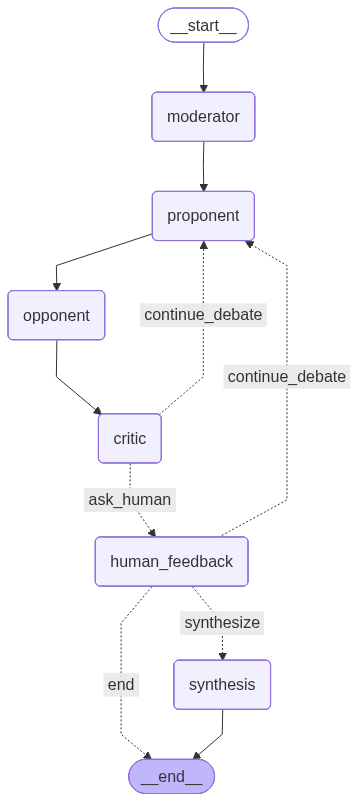

In [74]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Visualization requires optional dependencies: pip install pygraphviz")
    print("The graph will still work without visualization.")

## Step 11: Run the Debate Agent

Let's define a helper function to run debates with rich formatting.

In [75]:
def run_debate(topic: str, thread_id: str = "1") -> dict:
    """
    Run the full debate pipeline on a given topic.
    Returns the final state with synthesis and quality metrics.
    """
    pprint_header(f"DEBATE TOPIC: {topic}", "cyan")

    start_time = time.time()

    result = app.invoke(
        {
            "user_query": topic,
            "topic": "",
            "debate_rounds": 0,
            "max_rounds": 5,
            "quality_threshold": 7.5,
            "current_round": 1,
            "proponent_messages": [],
            "opponent_messages": [],
            "critic_feedback": [],
            "quality_scores": {},
            "avg_quality_score": 0.0,
            "logic_fallacies_found": [],
            "synthesis": "",
            "debate_summary": "",
            "user_feedback": "",
            "needs_human_intervention": True,
        },
        config={"configurable": {"thread_id": thread_id}},
    )

    elapsed = time.time() - start_time

    print()
    pprint_header("DEBATE COMPLETE", "green")
    pprint_info("Duration", f"{elapsed:.1f}s", "white")
    pprint_info("Rounds completed", str(result.get("current_round", "N/A")), "white")

    qual = result.get("avg_quality_score", 0)
    qual_color = "green" if qual >= 7.5 else ("yellow" if qual >= 5.0 else "red")
    pprint_info("Final quality score", f"{qual:.1f}/10", qual_color)

    fallacies = result.get("logic_fallacies_found", [])
    if fallacies:
        pprint_info("Logical fallacies", ", ".join(fallacies), "yellow")

    pprint_separator("=", 80, "green")

    return result

### Example 1: Everyday Topic

Let's start with a relatable topic that should reach consensus quickly.

In [76]:
result1 = run_debate("Is working from home better than working from an office?", thread_id="debate_1")

if result1.get("synthesis"):
    print()
    pprint_header("FINAL SYNTHESIS", "green")
    print(result1["synthesis"])
    print()
    print(f"{C['dim']}{result1.get('debate_summary', '')}{C['reset']}")

DEBATE TOPIC: Is working from home better than working from an office?
  >>> Moderator analyzing query...
  Moderator setup complete.
[Proponent (FOR)] Researching and constructing supporting arguments...

[Proponent] [Proponent agent error: Expecting value: line 1 column 1 (char 0). Using fallback response.] **Main Claim:** Working from home is better than working from an office due to its numerous benefits for em...

[Opponent (AGAINST)] Researching and constructing counter-arguments...

[Opponent] **Main Counter-Claim:** While working from home may have some benefits, it is not necessarily better than working from an office. In fact, remote work can have several drawbacks for employees, employe...

  >>> Critic evaluating both arguments...
  Avg Quality: 7.5/10
  Fallacies: Appeal to Authority (DuckDuckGo search results), False Dichotomy (assuming that remote work is either beneficial or detrimental, without considering nuance), Strawman (misrepresenting the opponent's argument or e

### Example 2: Controversial Topic

Now a more polarizing topic that will generate stronger disagreement.

In [77]:
result2 = run_debate("Should social media platforms be banned for users under 16?", thread_id="debate_2")

if result2.get("synthesis"):
    print()
    pprint_header("FINAL SYNTHESIS", "green")
    print(result2["synthesis"])
    print()
    print(f"{C['dim']}{result2.get('debate_summary', '')}{C['reset']}")

DEBATE TOPIC: Should social media platforms be banned for users under 16?
  >>> Moderator analyzing query...
  Moderator setup complete.
[Proponent (FOR)] Researching and constructing supporting arguments...

[Proponent] [Proponent agent error: Expecting value: line 1 column 1 (char 0). Using fallback response.] **Main Claim:** Social media platforms should be banned for users under 16 due to the significant risks the...

[Opponent (AGAINST)] Researching and constructing counter-arguments...

[Opponent] [Opponent agent error: Expecting value: line 1 column 1 (char 0). Using fallback response.] **Main Counter-Claim:** Banning social media platforms for users under 16 is not a viable solution, as it ca...

  >>> Critic evaluating both arguments...
  Avg Quality: 7.5/10
  Fallacies: Ad hominem attack (implied by the opponent's statement that the proponent's argument is 'not a viable solution for many young people, particularly those who are already online'), Straw man argument (implied by

## Key Takeaways

1. **Adversarial debate reduces bias** — forcing opposing viewpoints leads to more balanced conclusions
2. **Quality-based iteration** — the system self-improves until a quality threshold is met
3. **Human oversight** — you can review, redirect, or approve before the final synthesis
4. **Free and extensible** — uses free tools (DuckDuckGo, Wikipedia) and can be adapted to any LLM provider

### Customization Ideas
- Add more agent personas (e.g., Domain Expert, Devil's Advocate)
- Swap to different LLMs (GPT-4, Claude, Gemini) via OpenAI-compatible endpoints
- Extend the quality gate with additional metrics (novelty, persuasiveness)
- Add persistent storage (SQLite, Postgres) for debate history
- Integrate with web frameworks (Gradio, Streamlit) for a UI